# **Data Ingestion, Cleaning & Feature Engineering**

## **Upwork Job Market Analysis — End-to-End Data Science Project**

### **Project Overview**
This project performs a comprehensive analysis of **244,828 Upwork job postings** spanning November 2023 to March 2024, collected from 212 countries across 13 job domains.

The dataset captures:
- Job titles and posting timestamps
- Compensation structures (hourly rate vs. fixed-price budget)
- Client geography (country of origin)
- Job type flags (`is_hourly`)

### **Goals of this Notebook**
1. Load and inspect the raw dataset structure
2. Audit data quality — null values, dtypes, inconsistencies
3. Clean and standardize all columns
4. Engineer 9 new features for downstream analysis
5. Classify all jobs into 13 domain categories via keyword matching
6. Persist the cleaned dataset for all downstream notebooks


In [43]:

import os
import sys
import logging
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import re

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110})

# Ensure console output uses UTF-8 and replaces unsupported characters on Windows
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
if hasattr(sys.stderr, 'reconfigure'):
    sys.stderr.reconfigure(encoding='utf-8', errors='replace')

# ── Dual-output Logger ──────────────────────────────────────
os.makedirs('../logs', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../assets', exist_ok=True)

logger = logging.getLogger('NB01_Ingestion')
logger.setLevel(logging.DEBUG)
logger.handlers.clear()

fh = logging.FileHandler('../logs/01_data_ingestion.log', mode='w', encoding='utf-8')
fh.setLevel(logging.DEBUG)
fh.setFormatter(logging.Formatter('%(asctime)s | %(levelname)-8s | %(message)s'))

ch = logging.StreamHandler()
ch.setLevel(logging.INFO)
ch.setFormatter(logging.Formatter('%(levelname)-8s | %(message)s'))

logger.addHandler(fh)
logger.addHandler(ch)
logger.info("=== Notebook 01 started ===")
logger.info("Logger writing to: console (INFO) + logs/01_data_ingestion.log (DEBUG)")


INFO     | === Notebook 01 started ===
INFO     | Logger writing to: console (INFO) + logs/01_data_ingestion.log (DEBUG)


### **Step 1 — Load Raw Dataset**

We load the raw CSV and immediately log shape, column names, and the date range. This makes every pipeline run fully auditable — the log file records exactly what was loaded and when.


In [44]:
logger.info("Loading raw data from CSV...")
RAW_PATH = '../data/raw/upwork_jobs.csv'
df = pd.read_csv(RAW_PATH)

logger.info(f"Loaded → {df.shape[0]:,} rows × {df.shape[1]} columns")
logger.info(f"Columns: {df.columns.tolist()}")
logger.info(f"Date range: {df['published_date'].min()} → {df['published_date'].max()}")

print(f"Shape: {df.shape}")
df.head()
logger.info("Initial data loaded successfully.")

INFO     | Loading raw data from CSV...
INFO     | Loaded → 244,828 rows × 8 columns
INFO     | Columns: ['title', 'link', 'published_date', 'is_hourly', 'hourly_low', 'hourly_high', 'budget', 'country']
INFO     | Date range: 2023-11-02 09:22:02+00:00 → 2024-03-24 14:16:47+00:00
INFO     | Initial data loaded successfully.


Shape: (244828, 8)


In [45]:
logger.info("Checking for missing values...")
missing_summary = df.isnull().sum()
logger.info("Missing values per column:")
for col, count in missing_summary.items():
    logger.info(f"  {col}: {count} missing")
logger.info("Missing values check completed.")

# Data types overview
logger.info("Column dtypes:")
for col, dtype in df.dtypes.items():
    logger.info(f"  {col}: {dtype}")
logger.info("Column dtypes check completed.")
df.dtypes.to_frame('dtype')


INFO     | Checking for missing values...
INFO     | Missing values per column:
INFO     |   title: 1 missing
INFO     |   link: 1 missing
INFO     |   published_date: 0 missing
INFO     |   is_hourly: 0 missing
INFO     |   hourly_low: 142406 missing
INFO     |   hourly_high: 146053 missing
INFO     |   budget: 140937 missing
INFO     |   country: 5077 missing
INFO     | Missing values check completed.
INFO     | Column dtypes:
INFO     |   title: object
INFO     |   link: object
INFO     |   published_date: object
INFO     |   is_hourly: bool
INFO     |   hourly_low: float64
INFO     |   hourly_high: float64
INFO     |   budget: float64
INFO     |   country: object
INFO     | Column dtypes check completed.


,dtype
title,object
link,object
published_date,object
is_hourly,bool
hourly_low,float64
hourly_high,float64
budget,float64
country,object


### **Step 2 — Null Value Audit**

Before any cleaning we quantify missing values per column and express them as percentages.

> **Note:** High null rates in `hourly_low`, `hourly_high`, and `budget` are **structural**, not data quality issues — these columns are mutually exclusive by job type.


In [46]:
logger.info("Generating null value report...")
null_report = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct':   (df.isnull().sum() / len(df) * 100).round(2)
})

logger.info("Null value audit:")
for col, row in null_report.iterrows():
    logger.info(f"  {col}: {int(row['null_count']):,} nulls ({row['null_pct']:.1f}%)")

logger.info("Null value report generated successfully.")
null_report

INFO     | Generating null value report...
INFO     | Null value audit:
INFO     |   title: 1 nulls (0.0%)
INFO     |   link: 1 nulls (0.0%)
INFO     |   published_date: 0 nulls (0.0%)
INFO     |   is_hourly: 0 nulls (0.0%)
INFO     |   hourly_low: 142,406 nulls (58.2%)
INFO     |   hourly_high: 146,053 nulls (59.7%)
INFO     |   budget: 140,937 nulls (57.6%)
INFO     |   country: 5,077 nulls (2.1%)
INFO     | Null value report generated successfully.


,null_count,null_pct
title,1,0.00
link,1,0.00
published_date,0,0.00
is_hourly,0,0.00
hourly_low,142406,58.17
hourly_high,146053,59.66
budget,140937,57.57
country,5077,2.07


### **Step 3 — Data Cleaning**

Cleaning steps applied:
- Parse `published_date` to UTC-aware datetime
- Fill 5,077 missing `country` values with `'Unknown'`
- Drop the single fully-null row (title + link both null)
- No imputation on salary/budget — missingness is structural


In [47]:
logger.info("Cleaning data...")
df['published_date'] = pd.to_datetime(df['published_date'], utc=True)
logger.info("Parsed published_date → UTC datetime")

n_unknown = df['country'].isnull().sum()
df['country'] = df['country'].fillna('Unknown')
logger.info(f"Filled {n_unknown:,} missing country values with 'Unknown'")

before = len(df)
df.dropna(subset=['title', 'link'], inplace=True)
df.reset_index(drop=True, inplace=True)
logger.info(f"Dropped {before - len(df)} fully-null row(s) → {len(df):,} rows remain")

logger.info(f"Clean shape: {df.shape}")


INFO     | Cleaning data...
INFO     | Parsed published_date → UTC datetime
INFO     | Filled 5,077 missing country values with 'Unknown'
INFO     | Dropped 1 fully-null row(s) → 244,827 rows remain
INFO     | Clean shape: (244827, 8)


### **Step 4 — Feature Engineering**

We derive 9 new features to power EDA, trend analysis, and modelling:

| Feature | Description |
|---------|-------------|
| `avg_hourly` | Mean of `hourly_low` and `hourly_high` |
| `avg_hourly_capped` | Avg hourly clipped at 99.5th pct to remove extreme outliers |
| `budget_capped` | Budget clipped at 99.5th pct |
| `job_type` | String label: `'Hourly'` or `'Fixed-Price'` |
| `year_month` | `'YYYY-MM'` string for monthly grouping |
| `week` | ISO week number |
| `day_of_week` | Full day name (Monday … Sunday) |
| `hour` | Hour of day (UTC) |
| `category` | Domain classification from keyword matching |


In [48]:
logger.info("Engineering features...")
df['avg_hourly']        = df[['hourly_low', 'hourly_high']].mean(axis=1)
df['avg_hourly_capped'] = df['avg_hourly'].clip(upper=df['avg_hourly'].quantile(0.995))
df['budget_capped']     = df['budget'].clip(upper=df['budget'].quantile(0.995))
df['job_type']          = df['is_hourly'].map({True: 'Hourly', False: 'Fixed-Price'})
df['year_month']        = df['published_date'].dt.strftime('%Y-%m')
df['week']              = df['published_date'].dt.isocalendar().week.astype(int)
df['day_of_week']       = df['published_date'].dt.day_name()
df['hour']              = df['published_date'].dt.hour

logger.info("Engineered features: avg_hourly, avg_hourly_capped, budget_capped, "
            "job_type, year_month, week, day_of_week, hour")
df[['title', 'job_type', 'avg_hourly', 'budget', 'year_month', 'week', 'day_of_week']].head()
logger.info("Feature engineering completed.")

INFO     | Engineering features...
INFO     | Engineered features: avg_hourly, avg_hourly_capped, budget_capped, job_type, year_month, week, day_of_week, hour
INFO     | Feature engineering completed.


### **Step 5 — Job Category Classification**

We define 13 domain-specific keyword lists and scan each job title for a match. The **first matching category wins**; unmatched titles are labelled `'Other'`.

This rule-based approach is:
- Fast (vectorised string operations)
- Interpretable (explicit keyword lists)
- Accurate for structured job-board titles


In [49]:
logger.info("Classifying job categories based on title keywords...")
CATEGORY_KEYWORDS = {
    'Web Development':     ['web', 'html', 'css', 'wordpress', 'react', 'angular', 'vue',
                            'frontend', 'backend', 'full stack', 'fullstack', 'node', 'php',
                            'django', 'flask'],
    'Mobile Development':  ['android', 'ios', 'flutter', 'react native', 'mobile app',
                            'swift', 'kotlin'],
    'Data Science / AI':   ['machine learning', 'deep learning', 'nlp', 'ai ', 'artificial intelligence',
                            'data science', 'llm', 'gpt', 'tensorflow', 'pytorch', 'neural'],
    'Data Analysis':       ['data analyst', 'data analysis', 'excel', 'tableau', 'power bi',
                            'sql', 'pandas', 'spreadsheet'],
    'Graphic Design':      ['graphic design', 'logo', 'branding', 'illustrat', 'photoshop',
                            'figma', 'ui/ux', 'ux design', 'ui design'],
    'Writing / Content':   ['writer', 'writing', 'copywriting', 'content', 'blog',
                            'article', 'editor', 'proofreading'],
    'Marketing / SEO':     ['seo', 'marketing', 'social media', 'ppc', 'ads', 'google ads',
                            'facebook ads', 'email marketing', 'media buyer'],
    'DevOps / Cloud':      ['devops', 'kubernetes', 'aws', 'azure', 'gcp', 'cloud',
                            'linux', 'terraform', 'ci/cd'],
    'Video / Animation':   ['video', 'animation', 'after effects', 'premiere',
                            'motion graphic', 'youtube'],
    'Finance / Accounting':['accounting', 'bookkeeping', 'finance', 'quickbooks', 'tax', 'cpa'],
    'Customer Support':    ['customer support', 'virtual assistant', 'va ', 'customer service',
                            'helpdesk'],
    'Blockchain / Crypto': ['blockchain', 'crypto', 'web3', 'solidity', 'nft', 'defi',
                            'smart contract'],
}

def classify_job(title):
    t = str(title).lower()
    for cat, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in t for kw in keywords):
            return cat
    return 'Other'

df['category'] = df['title'].apply(classify_job)

logger.info("Category distribution:")
for cat, cnt in df['category'].value_counts().items():
    logger.info(f"  {cat}: {cnt:,} ({cnt / len(df) * 100:.1f}%)")

df['category'].value_counts().to_frame('count')
logger.info("Job category classification completed.")

INFO     | Classifying job categories based on title keywords...
INFO     | Category distribution:
INFO     |   Other: 117,317 (47.9%)
INFO     |   Web Development: 36,537 (14.9%)
INFO     |   Writing / Content: 21,773 (8.9%)
INFO     |   Marketing / SEO: 19,181 (7.8%)
INFO     |   Graphic Design: 13,795 (5.6%)
INFO     |   Video / Animation: 11,538 (4.7%)
INFO     |   Customer Support: 5,023 (2.1%)
INFO     |   Mobile Development: 4,758 (1.9%)
INFO     |   Data Science / AI: 4,413 (1.8%)
INFO     |   Data Analysis: 3,230 (1.3%)
INFO     |   Finance / Accounting: 3,206 (1.3%)
INFO     |   DevOps / Cloud: 2,283 (0.9%)
INFO     |   Blockchain / Crypto: 1,773 (0.7%)
INFO     | Job category classification completed.


### **Step 5a - Word Cloud**

INFO     | Initializing word cloud ...


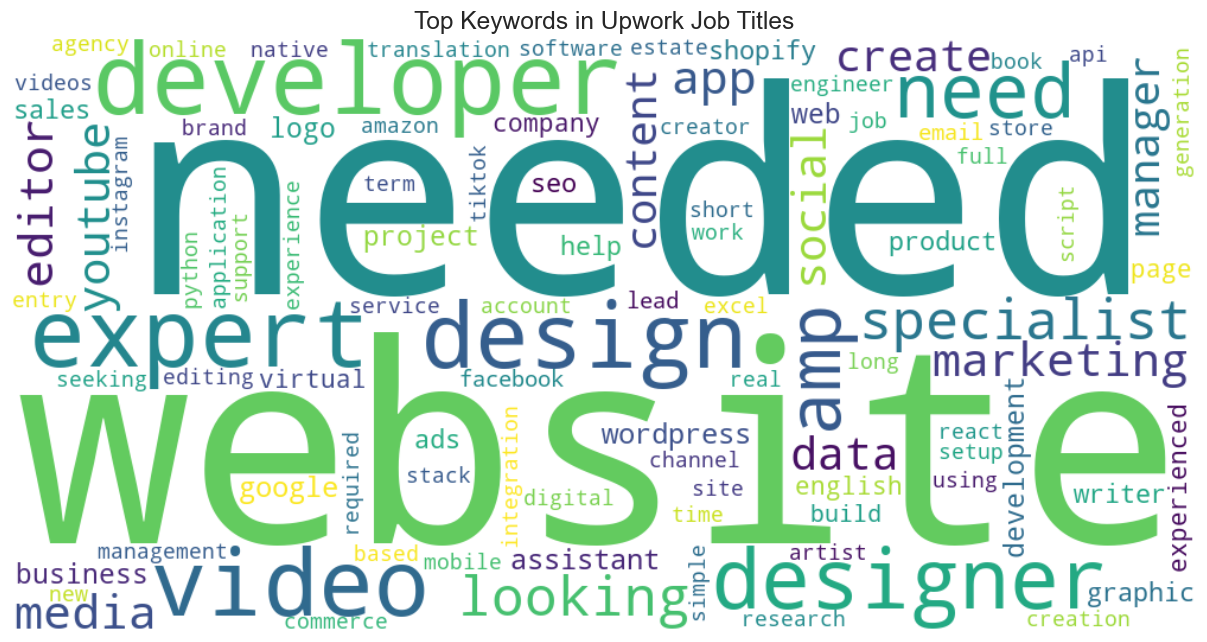

INFO     | Word cloud generated and displayed


In [50]:
logger.info("Initializing word cloud ...")
# Build clean title text
title_text = ' '.join(df['title'].dropna().astype(str).str.lower())
title_text = re.sub(r'[^a-z0-9\s]', ' ', title_text)

# Remove short words and stopwords
words = [
    word for word in title_text.split()
    if len(word) > 2 and word not in STOPWORDS
]

word_freq = Counter(words)
top_freq = dict(word_freq.most_common(100))

# Generate the word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(top_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Keywords in Upwork Job Titles', fontsize=16)
plt.show()
logger.info("Word cloud generated and displayed")

### **Step 6 — Save Cleaned Dataset**

The cleaned, feature-enriched dataset is written to `data/processed/` so every downstream notebook loads from a consistent, versioned baseline.


In [51]:
logger.info("Saving cleaned dataset to CSV...")
OUT_PATH = '../data/processed/upwork_clean.csv'
df.to_csv(OUT_PATH, index=False)
logger.info(f"=== Clean dataset saved to {OUT_PATH} | Shape: {df.shape} ===")

print(f"Saved: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   New features: avg_hourly, avg_hourly_capped, budget_capped,")
print(f"                 job_type, year_month, week, day_of_week, hour, category")
df.describe(include='all').T[['count', 'unique', 'top', 'mean', 'std', 'min', 'max']]
logger.info("Notebook 01 completed successfully.")

INFO     | Saving cleaned dataset to CSV...
INFO     | === Clean dataset saved to ../data/processed/upwork_clean.csv | Shape: (244827, 17) ===


Saved: 244,827 rows × 17 columns
   New features: avg_hourly, avg_hourly_capped, budget_capped,
                 job_type, year_month, week, day_of_week, hour, category


INFO     | Notebook 01 completed successfully.


## **Summary**

- Loaded and inspected the raw dataset for shape, column structure, and date coverage.
- Audited missing values and cleaned the data with timestamp parsing, country imputation, and invalid row removal.
- Engineered salary and temporal features plus job type labels for analysis.
- Classified each job title into a domain category using keyword matching.
- Saved the cleaned dataset as `data/processed/upwork_clean.csv` for use in downstream notebooks.